# SVM — Kernel Trick

## Step 1 — Why Do We Even Need the Kernel Trick?

Before learning the kernel trick, we need to understand **what problem it solves**.

---

## Recall the Original (Linear) SVM

A linear SVM learns a hyperplane

![image.png](attachment:69c968fe-ea67-4a9e-b85c-8ea7e1414647.png)

that separates two classes.

For example:

```
Class +
        +
             +
-------------------------- Hyperplane
     -
  -
       -

Class -
```

This works **only if the data is linearly separable** (or approximately so with a soft margin).

---

## But Many Real Datasets Are Not Linear

Suppose our dataset looks like this.

```
           +
      +         +

          -

      -         -

           +
```

Or even more commonly:

```
        +
     +     +

   +         +

      ---------

        -

     -     -

   -         -
```

No straight line can separate them.

---

### An Even Better Example

Imagine the positive class is in the center.

```
        -
    -       -

       + + +
      + + + +
       + + +

    -       -
        -
```

Here,

* Positive = center
* Negative = outside

Can one straight line separate them?

**No.**

No matter how you rotate a line,

```
------------
```

or

```
|
|
|
```

or

```
\
 \
  \
```

it will always cut through both classes.

---

## Why Doesn't Linear SVM Work?

Linear SVM searches only for equations of the form

![image.png](attachment:08d5d47f-1bde-4920-8f7f-c348d8b2fa5c.png)

which are always **linear**.

In 2D:

* line

In 3D:

* plane

In higher dimensions:

* hyperplane

It **cannot** produce curves like

* circles
* ellipses
* parabolas
* complex boundaries

---

## What Do We Actually Need?

Instead of a straight line,

we need something like

```
      ---------
     /         \
    /   + + +   \
   |   + + + +   |
    \   + + +   /
     \         /
      ---------

Outside = -
Inside = +
```

That is,

a **non-linear decision boundary**.

---

## The Main Question

If SVM can only find a **linear hyperplane**, then

> **How can SVM classify data that requires a curved boundary?**

This exact problem led to the development of the **Kernel Trick**.

---

# SVM — Kernel Trick

## Step 2 — The Core Idea: Transform the Data to a Higher Dimension

In the previous step, we saw that some datasets **cannot be separated by a straight line** in the original feature space.

The natural question is:

> **Can we somehow change the representation of the data so that a straight line becomes sufficient?**

The answer is **Yes**.

---

# Original Feature Space

Assume each data point has two features:

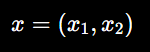

So every point lies in **2D space**.

Example:

| Point | (x_1) | (x_2) |
| ----- | ----- | ----- |
| A     | 1     | 2     |
| B     | 3     | 1     |
| C     | 2     | 4     |

Graphically,

```text
          x₂
          ↑
      •
            •
   •
----------------------→ x₁
```

Everything lives in **2 dimensions**.

---

# Suppose the Data Looks Like This

```text
          -
      -       -

         + + +
        + + + +
         + + +

      -       -
          -
```

This is **not linearly separable** in 2D.

No equation

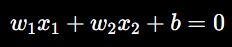

can separate these classes.

---

# Instead of Changing the Separator...

One possibility is to change the separator from a line to a curve.

But SVM is designed to find the **maximum-margin hyperplane**, which is always linear.

So instead of changing the separator,

**we change the data.**

---

# The Idea

Instead of representing every point by

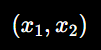

we represent it by a **new set of features**.

For example,

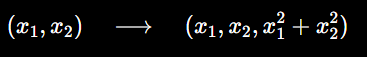

Notice that we added **one extra feature**.

Originally,

Number of features:

**`2`**

After transformation:

**`3`**

Now every point exists in **3D space** instead of 2D.

---

# This Transformation is Called Feature Mapping

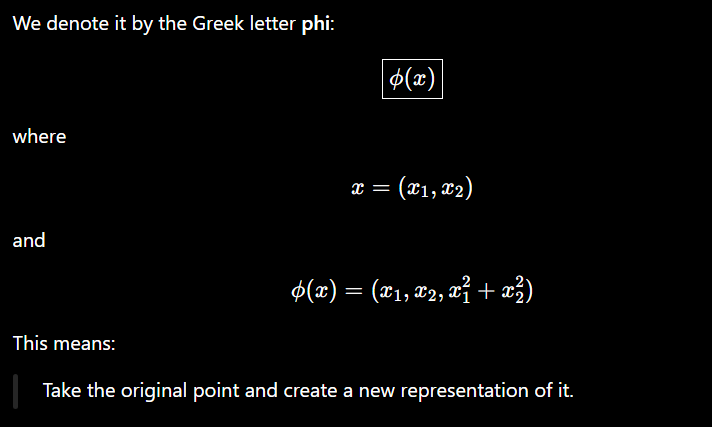
---

# Example

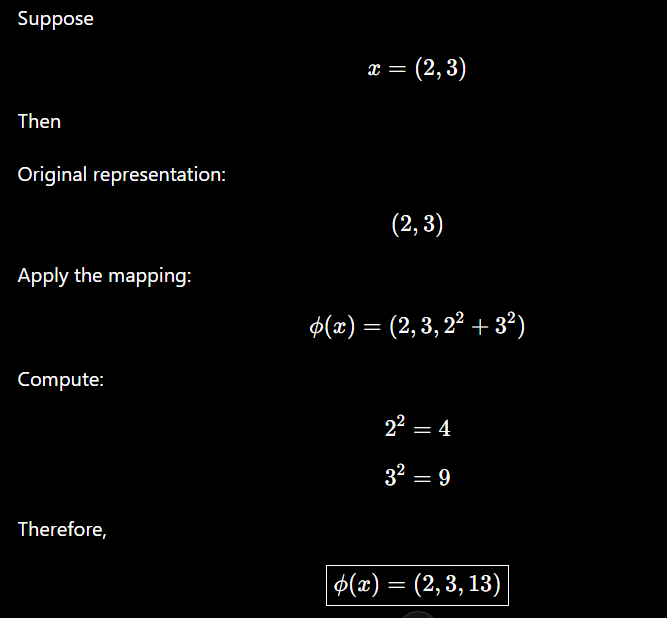

The point that originally had only **2 coordinates** now has **3 coordinates**.

---

# Another Example

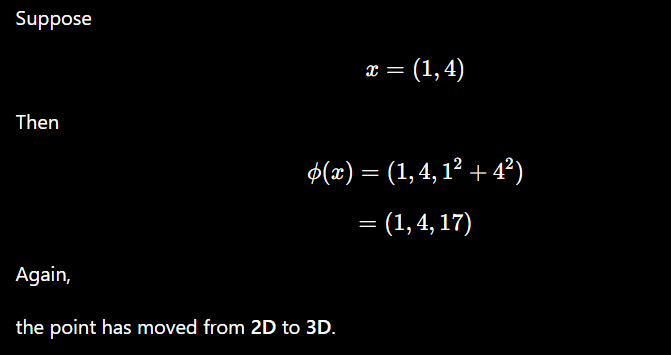

---

# Why Does This Help?

The important idea is:

The data itself has **not changed**.

Only its **representation** has changed.

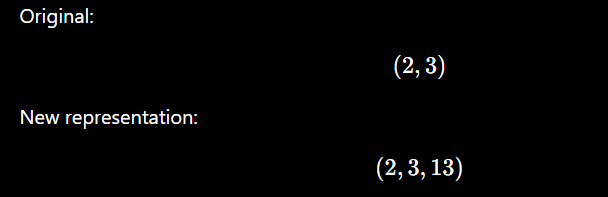

We're describing the **same sample**, but with additional information (a new feature).

This extra dimension can make patterns that were impossible to separate in 2D become separable by a **plane** in 3D.

---

# Summary

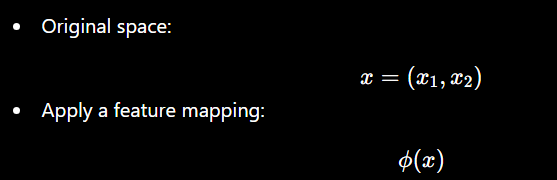

* New representation contains additional features.
* The data moves from a low-dimensional space to a higher-dimensional feature space.
* The goal is that the transformed data becomes **linearly separable** there.

---

That's a very important question. **"Inner" and "Outer"** are **not special SVM terms**. They are just describing a point's **distance from the origin (0,0)**.

Let's understand this carefully.

---

# Consider the Coordinate System

```text
          y
          ↑
          |
     (-2,2)      (2,2)
          |
----------O--------------→ x
          |
     (-2,-2)    (2,-2)
```

The point

[
O=(0,0)
]

is called the **origin**.

---

# Inner Points

An **inner point** is simply a point that is **close to the origin**.

Example:

[
(1,1)
]

Distance from origin:

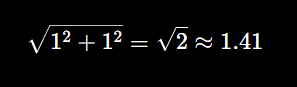

This is a small distance.

So

```text
          y
          ↑

        ● (1,1)

----------O--------------→ x
```

The point is **near** the center.

Hence it is called an **inner point**.

---

Another example:

[
(0,2)
]

Distance:

[
\sqrt{0^2+2^2}=2
]

Still fairly close.

So it is also an **inner point**.

---

# Outer Points

Now consider

[
(5,4)
]

Distance:

[
\sqrt{5^2+4^2}
==============

\sqrt{41}
\approx6.4
]

This point is much farther from the origin.

```text
                ● (5,4)





----------O----------------------------→ x
```

So it is called an **outer point**.

---

Another example:

[
(-6,3)
]

Distance:

[
\sqrt{36+9}
===========

\sqrt{45}
\approx6.7
]

Again,

far from the center.

Hence,

an **outer point**.

---

# Why Does This Matter?

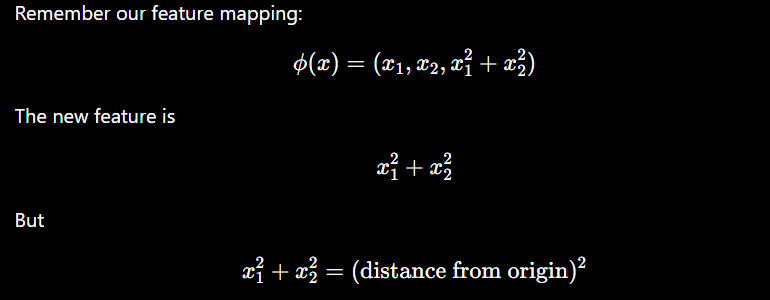

So:

| Point  | Distance from Origin | (x_1^2+x_2^2) |
| ------ | -------------------: | ------------: |
| (1,1)  |                 1.41 |             2 |
| (2,1)  |                 2.24 |             5 |
| (5,4)  |                 6.40 |            41 |
| (-6,3) |                 6.70 |            45 |

Notice:

* **Inner points** (close to the origin) have **small** values of (x_1^2+x_2^2).
* **Outer points** (far from the origin) have **large** values of (x_1^2+x_2^2).

---

# In Our Example

Our dataset looked like this:

```text
          -
      -       -

         + + +
        + + + +
         + + +

      -       -
          -
```

Here:

* The **+ points** are clustered near the center → **inner points**.
* The **− points** form a ring around them → **outer points**.

So after adding the feature (x_1^2+x_2^2):

* The **+ points** get **small** values.
* The **− points** get **large** values.

This difference is what allows SVM to separate them with a plane in the transformed space.

> **Important:** "Inner" and "outer" depend entirely on the dataset. In this example, "inner" means closer to the origin because our transformation uses the distance from the origin. They are not fixed SVM concepts that apply to every dataset.


# SVM — Kernel Trick

## Step 3 — How Does Higher Dimension Make the Data Linearly Separable?

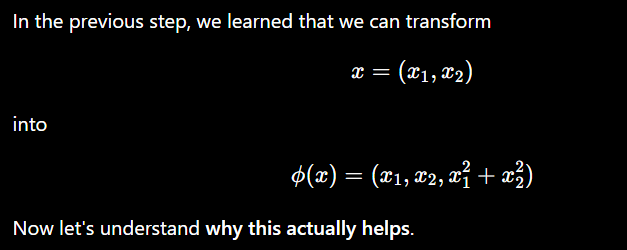

---

# Step 3.1 — Consider Our Circular Dataset

Suppose our data is:

```text
          -
      -       -

         + + +
        + + + +
         + + +

      -       -
          -
```

where

* **+** = Positive class
* **−** = Negative class

Notice something:

The **positive points are close to the origin**.

The **negative points are farther away**.

---

# Step 3.2 — What Is the New Feature?

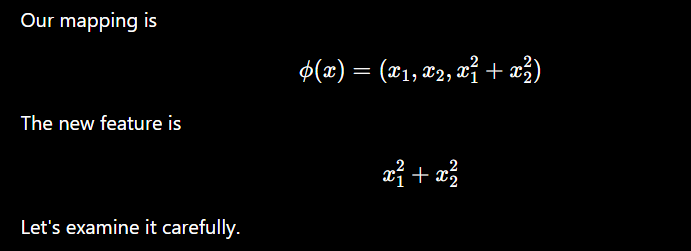

---

## What does (x_1^2+x_2^2) represent?

From geometry,

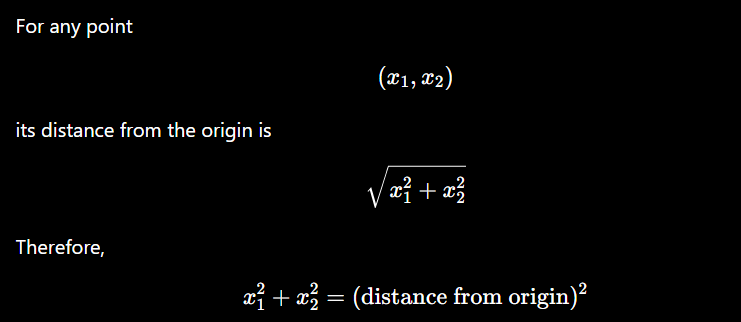

So our new feature is simply

> **the squared distance from the origin.**

This is a very important observation.

---

# Step 3.3 — Compute the New Feature

Let's compute it for some points.

---

### Positive Point

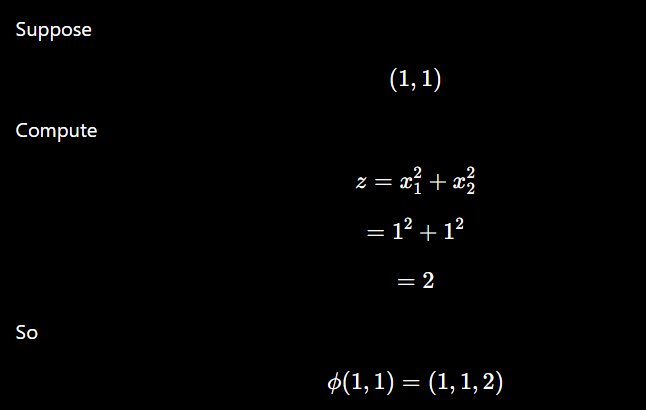

---

### Another Positive Point

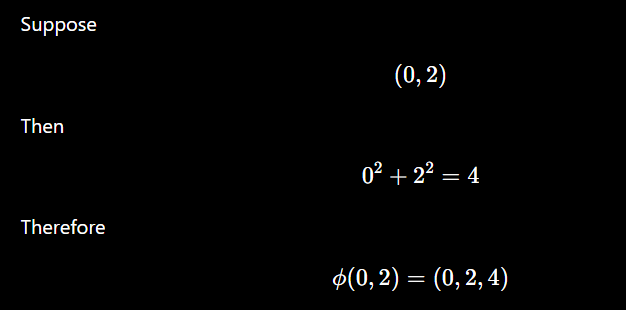

---

### Negative Point

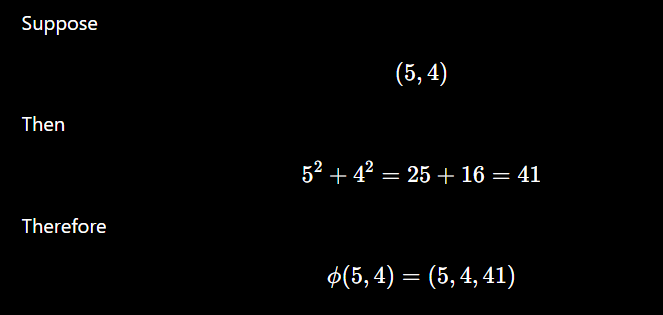

---

### Another Negative Point

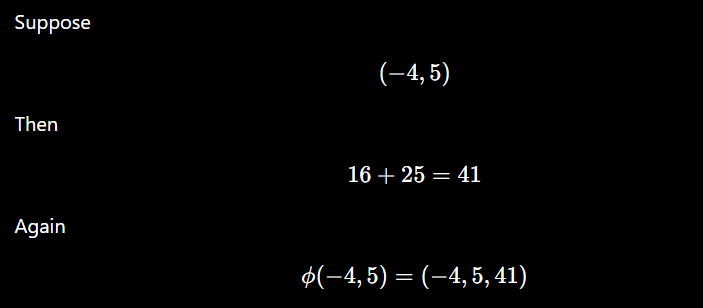

---

# Step 3.4 — Compare the New Feature

| Original Point | Class | (x_1^2+x_2^2) |
| -------------- | ----- | ------------: |
| (1,1)          | +     |             2 |
| (0,2)          | +     |             4 |
| (5,4)          | −     |            41 |
| (-4,5)         | −     |            41 |

Notice the pattern.

Positive points:

* 2
* 4
* 3
* 5

Negative points:

* 40
* 41
* 45
* 38

The **positive class has small values**, while the **negative class has large values**.

The new feature clearly separates the two groups.

---

# Step 3.5 — Visualize in 3D

Originally, every point was on the **2D plane**.

```text
      x₂

          •

    •

               •

----------------------→ x₁
```

After transformation, every point gets a height equal to

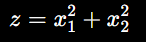

Now the space looks like this:

```text
             z
             ↑

             •      ← Negative (high z)

        •

-------------------------- x₁

      •
          •      ← Positive (low z)

          x₂
```

The important observation is:

* Positive points stay **near the bottom**.
* Negative points move **much higher** because they are farther from the origin.

---

# Step 3.6 — Now a Plane Can Separate Them

Since the classes are now separated mainly by their **z-value**, we can place a flat plane between them.

```text
             z
             ↑

      -      -

========================   ← Separating Plane

      +      +

------------------------→
```

Everything above the plane belongs to one class.

Everything below belongs to the other.

This is exactly what a **linear SVM** needs:

a **linear hyperplane**.

---

# The Key Insight

In **2D**, the boundary would need to be a **circle**, which is **non-linear**.

In the transformed **3D space**, the same problem can be solved using a **plane**, which **is linear**.

So the SVM **never learns a curved boundary in the higher-dimensional space**.

It always learns a **linear hyperplane** there.

When that hyperplane is viewed back in the original 2D space, it appears as a **curved (non-linear) decision boundary**.

---

## Summary

* We added a new feature:
*
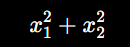

* This feature measures how far a point is from the origin.
* Inner points get **small** values.
* Outer points get **large** values.
* In the transformed 3D space, a simple **plane** can separate the classes.
* That plane corresponds to a **curved boundary** in the original 2D space.

---

# SVM — Kernel Trick

## Step 4 — The Problem with Explicit Feature Mapping

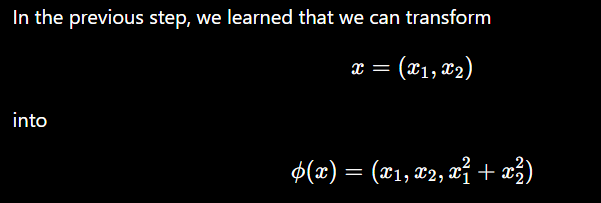

and then train a **linear SVM** in this new space.

At this point, you might ask:

> **If this works, why don't we always transform the data first?**

This is exactly the problem that led to the **Kernel Trick**.

---

# Step 4.1 — A Small Feature Mapping is Easy

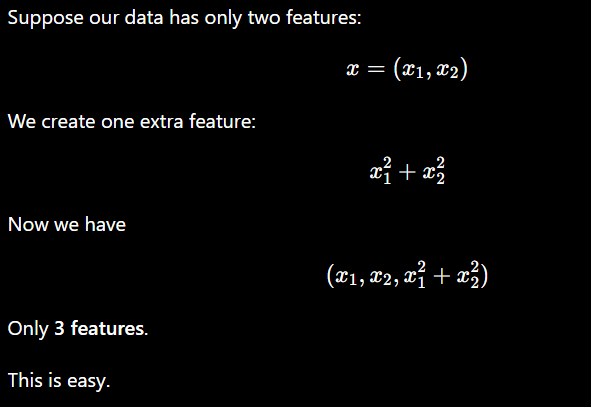

---

# Step 4.2 — What If We Want a Better Transformation?

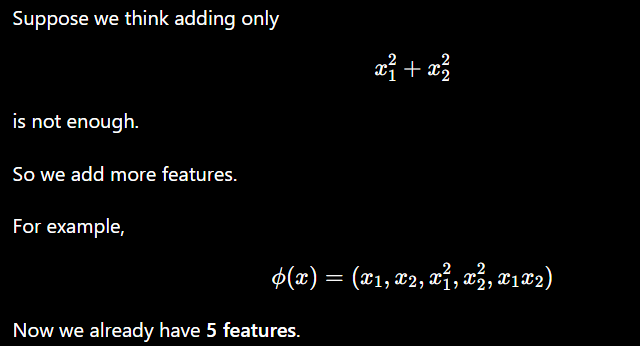

---

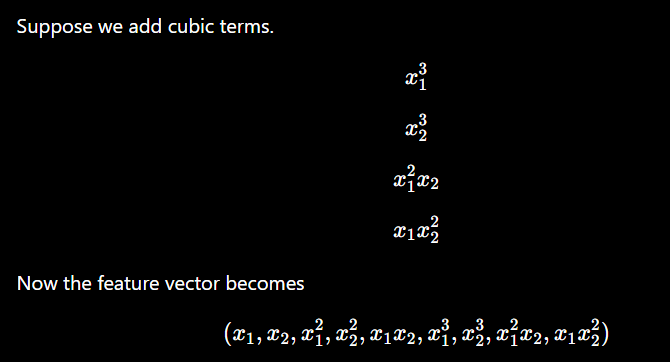

Now we have **9 features**.

The number of features is already growing rapidly.

---

# Step 4.3 — Imagine Real Datasets

Real datasets rarely have only two features.

Suppose

Original features

**`100`**

Now suppose we want all polynomial terms of degree 2.

Examples:

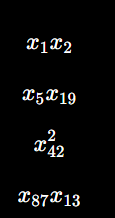

Instead of 100 features,

we may end up with **thousands of new features**.

---

Suppose we use degree 3.

The number of generated features becomes much larger.

Degree 4...

Even larger.

The feature space can become **millions of dimensions**.

---

# Step 4.4 — Why Is This a Problem?

Every transformed sample must now store all those features.

Example:

Original point

`**(2,3)**`

Stored as

```
2
3
```

Only **2 numbers**.

---

After transformation

```
2
3
4
9
6
8
27
...
```

Many more numbers must be stored.

Now imagine

* 1 million training samples
* each transformed into 200,000 features

Memory usage becomes enormous.

---

# Step 4.5 — Training Also Becomes Slow

Remember what SVM computes.

It repeatedly calculates

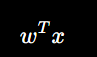

If every point has

* 2 features → easy
* 100 features → okay
* 10,000 features → slower
* 1,000,000 features → very expensive

Training time increases dramatically.

---

# Step 4.6 — There Is an Even Bigger Problem

Recall the **dual formulation** of SVM.

The optimization problem is

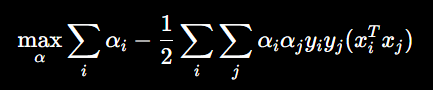

Notice something important.

The training algorithm **never directly uses** the feature vectors in the primal form.

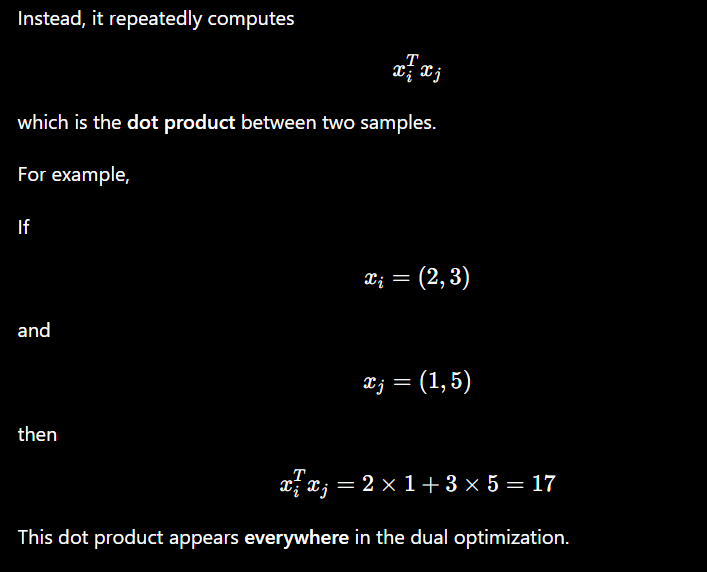

---

# Step 4.7 — After Feature Mapping

Now suppose we transform the points.

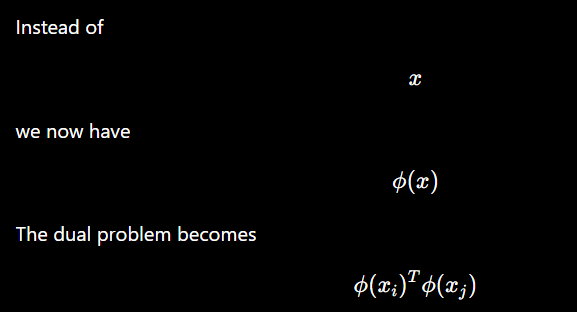

That means SVM only needs the **dot product of the transformed vectors**.

It does **not** need the transformed vectors themselves for the optimization.

This observation is the key breakthrough.

---

# The Big Question

If SVM only needs

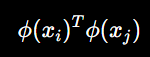

then why should we spend time:

* explicitly creating (\phi(x)),
* storing thousands or millions of new features,
* and then computing the dot product?

Wouldn't it be much better if we could compute

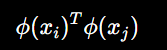

**directly**, without ever constructing (\phi(x))?

That is exactly the motivation behind the **Kernel Trick**.

---

# SVM — Kernel Trick

## Step 5 — The Kernel Trick

This is the **most important step** in understanding kernels.

Everything we learned so far was building toward this idea.

---

# Step 5.1 — Recall the Dual Formulation

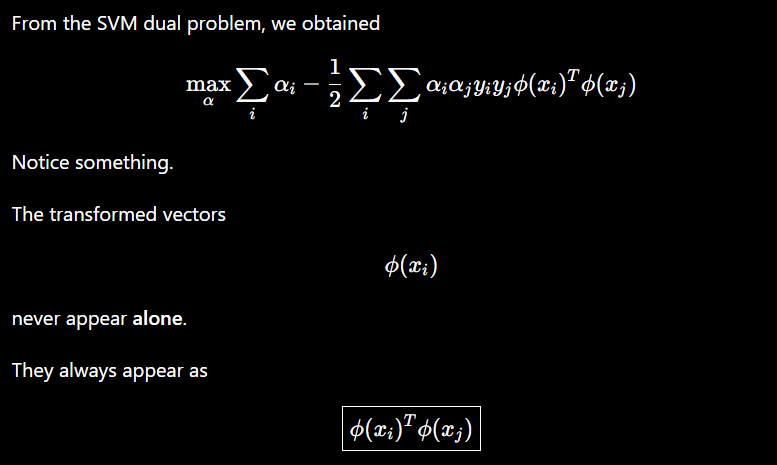

---

# Step 5.2 — What Is the Expensive Part?

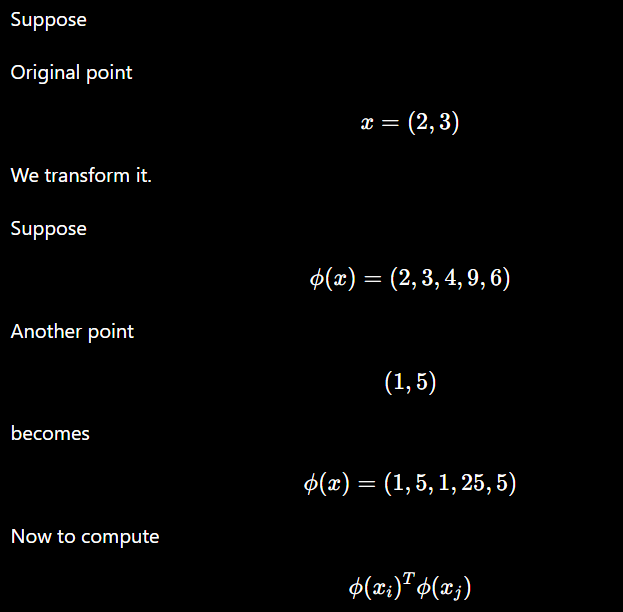

we first have to

1. Compute both transformed vectors.
2. Store them.
3. Multiply every corresponding component.
4. Add them together.

For a few features, this is easy.

For millions of features, it becomes extremely expensive.

---

# Step 5.3 — The Brilliant Observation

Suppose someone tells you:

> "I don't care about the transformed vectors."

> "I only need their dot product."

Then why compute the entire vectors?

Instead, we can directly compute the final answer.

This is exactly what the kernel function does.

---

# Step 5.4 — Definition of a Kernel Function

A **kernel function** is defined as

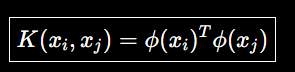

This is the most important equation in the Kernel Trick.

Let's understand every symbol.

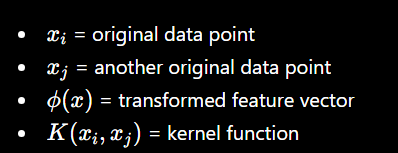

The kernel function returns **exactly the same value** as the dot product in the transformed space.

---

# Step 5.5 — What Makes It a "Trick"?

Normally, you would do this:

```text
Original Data
      │
      ▼
Compute φ(x)
      │
      ▼
Store High-Dimensional Vectors
      │
      ▼
Compute Dot Product
```

With a kernel, you do this instead:

```text
Original Data
      │
      ▼
Kernel Function
      │
      ▼
Dot Product in Higher Dimension
```

Notice something amazing.

The middle step

```text
Compute φ(x)
```

**completely disappears.**

We never explicitly create the high-dimensional vectors.

---

# Step 5.6 — An Analogy Using Numbers

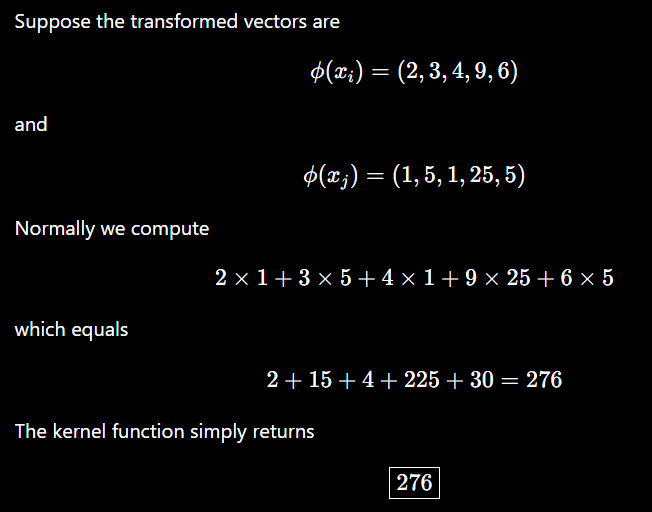

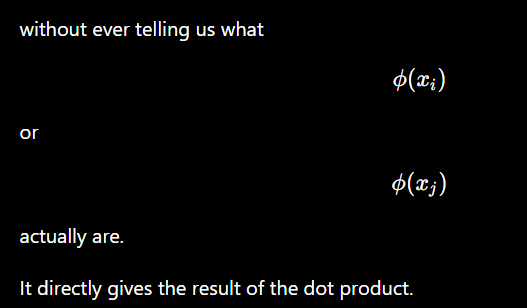

---

# Step 5.7 — Why Is This Amazing?

Imagine

Instead of 5 dimensions,

the transformed vectors have

**`1,000,000`**

dimensions.

Normally you would have to

* create one million features,
* store them,
* multiply one million numbers,
* add them.

A good kernel function computes the **same final answer** using only the **original features**.

For example,

Original data may have only

[
100
]

features,

yet the kernel behaves **as if** it worked in a space with millions (or even infinitely many) dimensions.

---

# Step 5.8 — Why Doesn't This Change the SVM?

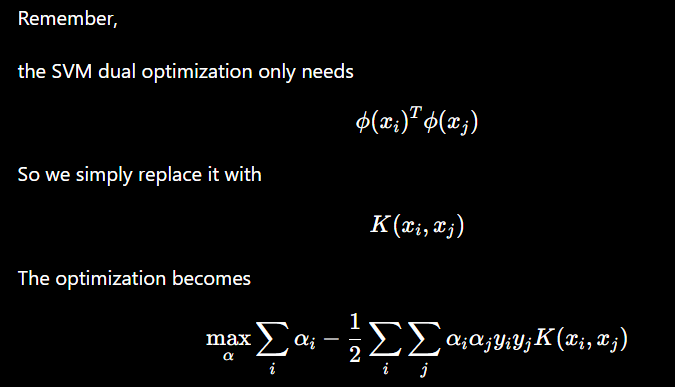

Nothing else changes.

The SVM algorithm is exactly the same.

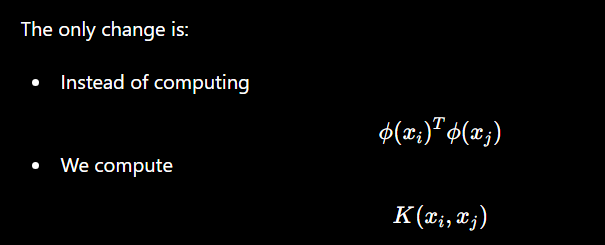

---

# Final Intuition

Think of the kernel as a **shortcut**.

Instead of

```text
Original Data
      │
      ▼
High-Dimensional Mapping φ(x)
      │
      ▼
Dot Product
```

we use

```text
Original Data
      │
      ▼
Kernel Function K(xi,xj)
      │
      ▼
Same Dot Product
```

Both approaches produce the **same mathematical value**, but the kernel avoids the expensive intermediate computation.

---

## Summary

* A kernel function is defined as:

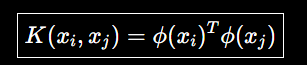


* It computes the dot product in the transformed feature space.
* It does **not** explicitly compute or store the transformed vectors.
* The SVM optimization problem remains unchanged except that every transformed dot product is replaced by the kernel function.
* This is why it is called the **Kernel Trick**: we get the effect of working in a high-dimensional space without explicitly going there.

---

###  **Understanding **(x_i)** and **(x_j)** is essential for understanding kernels.**

---

# What are (x_i) and (x_j)?

They are simply **two data points (samples)** from your training dataset.

Suppose your dataset is:

| Sample | Feature 1 | Feature 2 | Label |
| ------ | --------: | --------: | ----: |
| (x_1)  |         2 |         3 |    +1 |
| (x_2)  |         1 |         5 |    -1 |
| (x_3)  |         4 |         2 |    +1 |
| (x_4)  |         6 |         1 |    -1 |

Here,

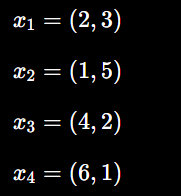

Each (x_k) is **one complete training example**.

---

# Why Do We Use (i) and (j)?

In the SVM dual optimization, we compare **every pair of training samples**.

So we use two indices:

* (i) → first sample
* (j) → second sample

For example,

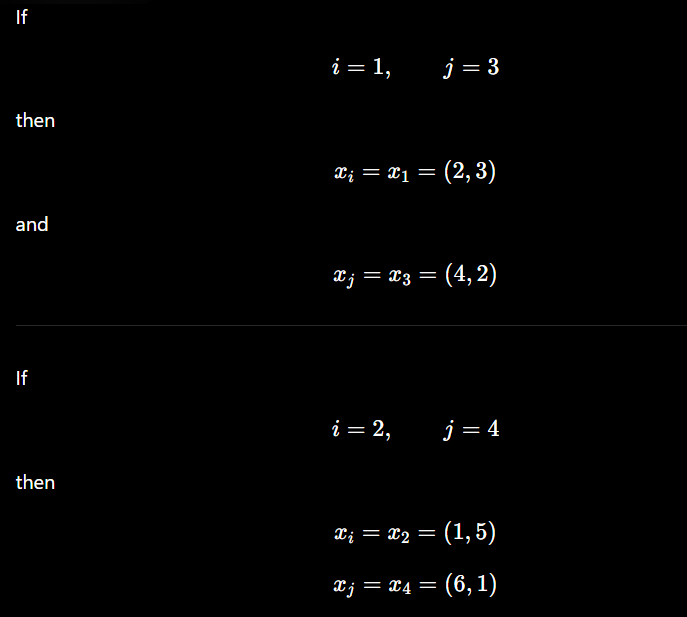

---

# Why Compare Two Samples?

Remember the dual objective:

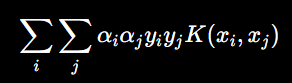

This means:

For **every sample (x_i)**,

compare it with **every sample (x_j)**.

If there are 4 samples:

```
x₁
x₂
x₃
x₄
```

the SVM computes:

| (x_i) | (x_j) |
| ----- | ----- |
| (x_1) | (x_1) |
| (x_1) | (x_2) |
| (x_1) | (x_3) |
| (x_1) | (x_4) |
| (x_2) | (x_1) |
| (x_2) | (x_2) |
| ...   | ...   |
| (x_4) | (x_4) |

Every possible pair is considered.

---

# What Does (K(x_i, x_j)) Mean?

It means:

> **Take sample (x_i) and sample (x_j), then compute how similar they are in the transformed feature space.**

For example,

Suppose
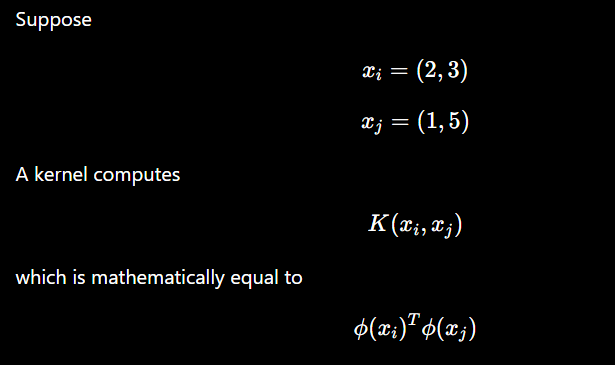

Notice that the inputs to the kernel are still the **original data points**.

---

# Visual Example

Suppose your dataset has three points:

```text
Sample 1 : x₁ = (2,3)

Sample 2 : x₂ = (1,5)

Sample 3 : x₃ = (4,2)
```

Then the kernel may compute:

```
K(x₁, x₁)

K(x₁, x₂)

K(x₁, x₃)

K(x₂, x₂)

K(x₂, x₃)

K(x₃, x₃)
```

Each computation compares **two training samples**.

---

# Don't Confuse the Subscript

Many students think:

**`x_i`**

means the **(i)-th feature**.

**It does not.**

Instead,

**`x_i`**

means the **entire (i)-th training sample**.

For example, if your dataset is:

| Sample | Features |
| ------ | -------- |
| (x_1)  | (2, 3)   |
| (x_2)  | (1, 5)   |
| (x_3)  | (4, 2)   |

then:

* (x_2) is **not** the second feature.
* (x_2) is the **entire second training example**, i.e., ((1,5)).

---

## Summary

* (x_i) = the **(i)-th training sample**.
* (x_j) = the **(j)-th training sample**.
* (i) and (j) are just indices used to select two samples.
* (K(x_i, x_j)) computes the similarity (or equivalently, the transformed-space dot product) between those two samples.
* The SVM dual algorithm evaluates this kernel for **every pair of training samples**.

# SVM — Kernel Trick

## Step 6 — How Does a Kernel Compute the Dot Product Without Computing (\phi(x))?

This is the part that feels like "magic" at first.

We'll see that it is actually **pure mathematics**, not magic.

---

# Step 6.1 — Let's Start with a Simple Feature Mapping

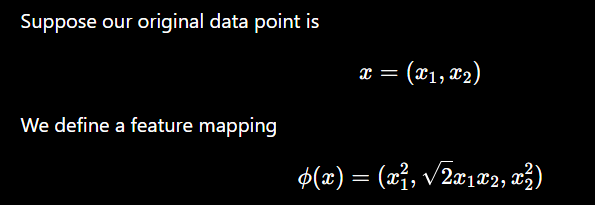

Notice something:

Originally,

**`x`**

had **2 features**.

After mapping,

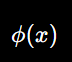

has **3 features**.

---

# Step 6.2 — Take Two Training Samples

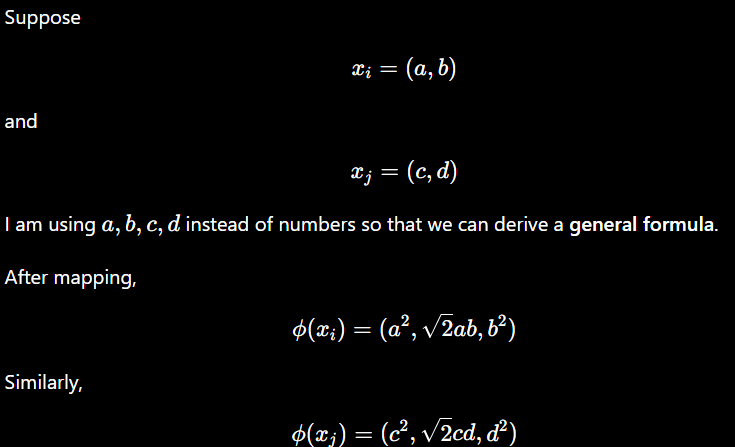

---

# Step 6.3 — Compute the Dot Product

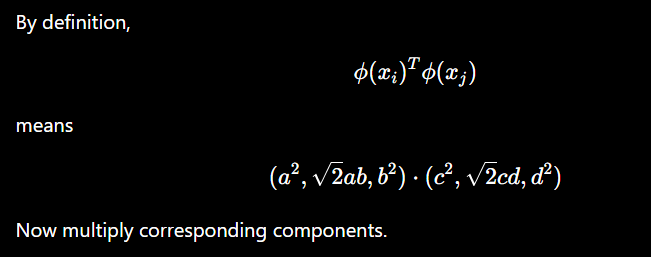

First component:

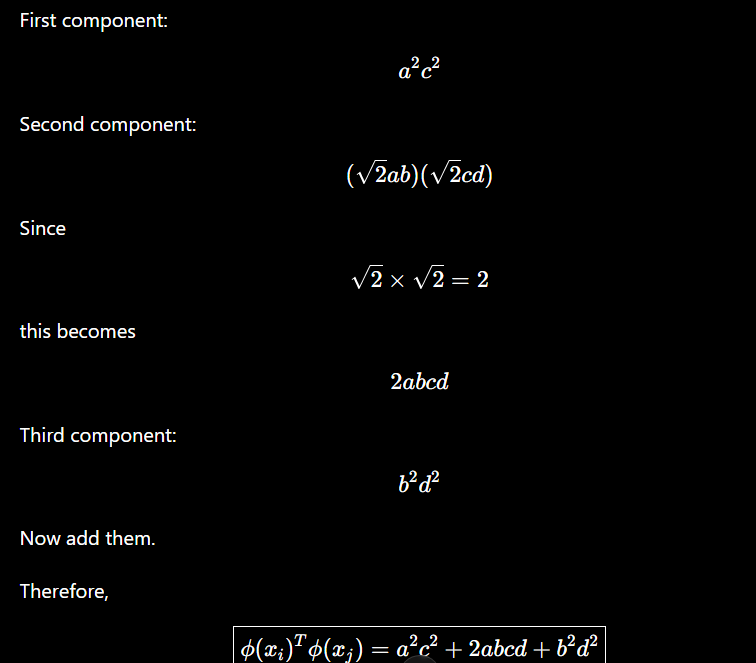

---

# Step 6.4 — Does This Expression Look Familiar?

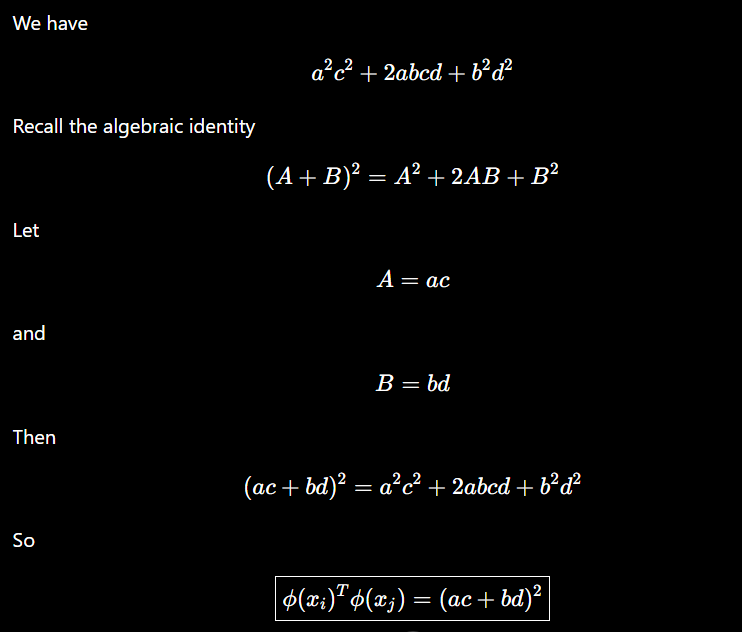

---

# Step 6.5 — But What Is (ac+bd)?

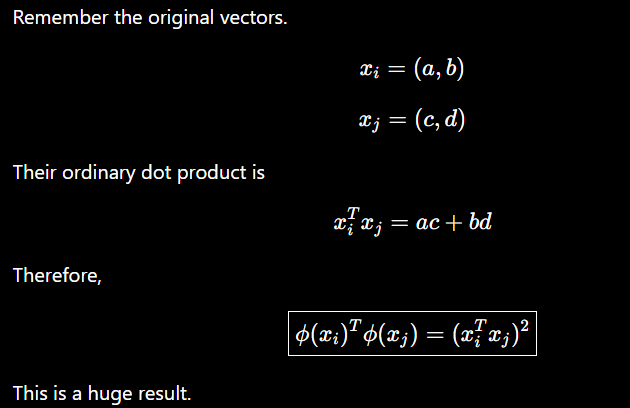

---

# Step 6.6 — Define the Kernel

Instead of computing

1. the feature mapping,
2. the transformed vectors,
3. their dot product,

we simply compute

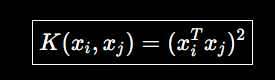

This gives **exactly the same answer**.

---

# Step 6.7 — Numerical Verification

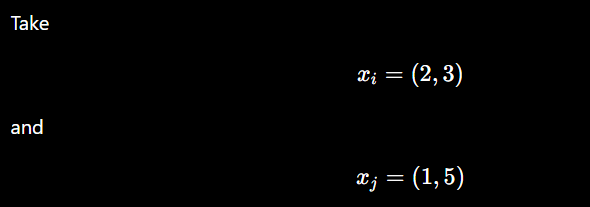

---

### Method 1 — Explicit Mapping

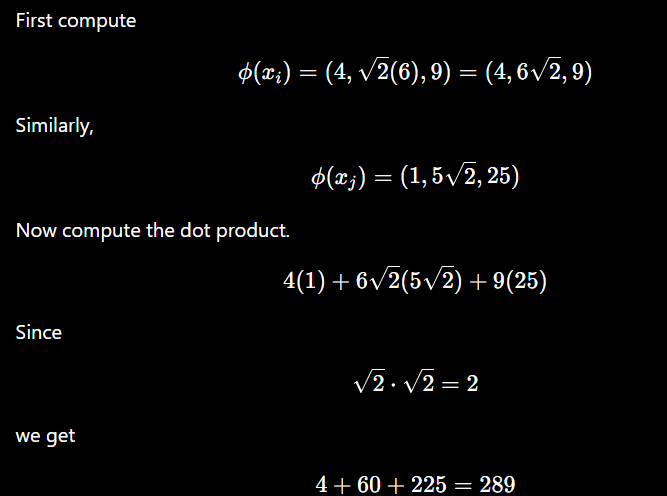

---

### Method 2 — Kernel

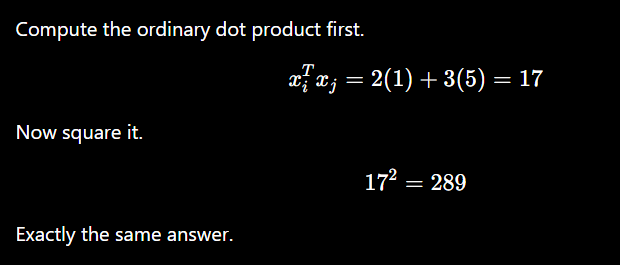

---

# Why Is This Amazing?

Without the kernel:

```text
Original vectors
        │
        ▼
Compute φ(x)
        │
        ▼
3-dimensional vectors
        │
        ▼
Dot Product = 289
```

With the kernel:

```text
Original vectors
        │
        ▼
Compute xᵢᵀxⱼ
        │
        ▼
Square it
        │
        ▼
289
```

We **never computed** the transformed vectors, yet we obtained the **exact same result**.

---

# The Big Idea

The kernel function

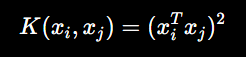

behaves **as if** we had mapped the data into a higher-dimensional space, even though we never explicitly created those higher-dimensional vectors.

This is why it is called the **Kernel Trick**.

---

## Summary

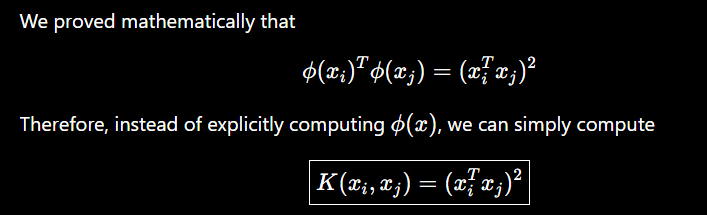

This is the **Polynomial Kernel of degree 2**.

Notice that there is **no trick or approximation** here—the kernel returns **exactly the same value** as the dot product in the transformed feature space.

---

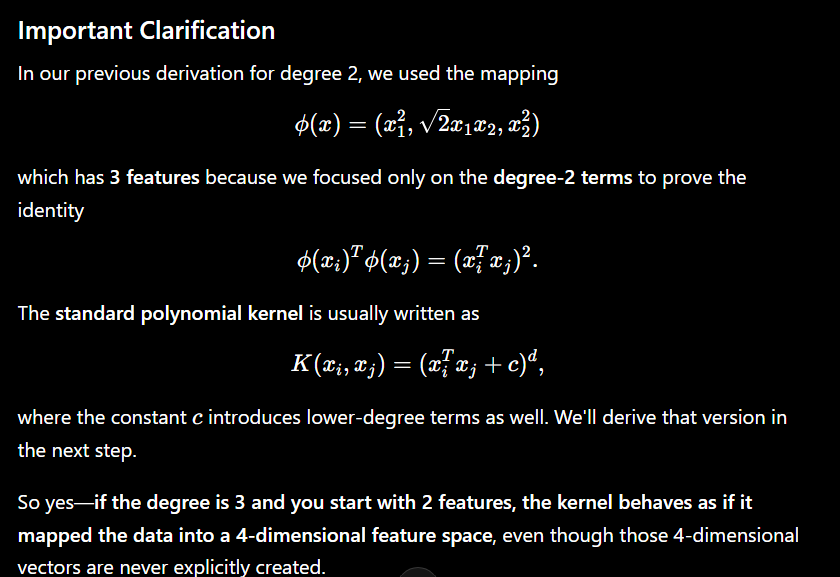